##  Lagrange Interpolation

In [29]:
import matplotlib.pyplot as plt
import numpy as np

In [30]:
x_data = [0,   1,      2.5,     3,       4.5,     5,       6    ]
y_data = [2.0, 5.4375, 7.35160, 7.56250, 8.44530, 9.18750, 12.0 ]
 
TARGET = 3.5

Helper: compute ONE Lagrange basis polynomial Li(x)

In [31]:
def lagrange_basis(i, x_nodes, x):
    """
    Compute Li(x) for a given set of nodes (x_nodes).
    
    Li(x) = product of (x - xj) / (xi - xj)  for all j != i
    
    Parameters
    ----------
    i       : index of the basis polynomial (0-based)
    x_nodes : list of x coordinates of the chosen nodes
    x       : the point where we want to evaluate Li
    
    Returns
    -------
    Li_value : float
    """
    n       = len(x_nodes)
    Li      = 1.0                       # start with multiplicative identity
 
    for j in range(n):
        if j == i:                      # skip the i-th node
            continue
        numerator   = x - x_nodes[j]
        denominator = x_nodes[i] - x_nodes[j]
        Li          = Li * (numerator / denominator)
 
    return Li

Helper: evaluate the full Lagrange polynomial Pk(x)

In [32]:
def lagrange_interpolate(x_nodes, y_nodes, x):
    """
    Evaluate the Lagrange interpolating polynomial at point x.
 
    P(x) = sum of  yi * Li(x)   for i = 0 .. n-1
 
    Parameters
    ----------
    x_nodes : list of x coordinates of chosen nodes
    y_nodes : list of corresponding y values
    x       : evaluation point
 
    Returns
    -------
    result : float  – the estimated function value at x
    """
    n      = len(x_nodes)
    result = 0.0
 
    for i in range(n):
        Li      = lagrange_basis(i, x_nodes, x)
        result  = result + y_nodes[i] * Li
 
    return result
 

Node selection: pick nodes closest to TARGET

In [33]:
def get_closest_nodes(x_data, y_data, target, num_nodes):
    """
    Sort all data points by their distance from `target` and
    return the `num_nodes` closest ones.
 
    Returns x_nodes, y_nodes  (as plain lists)
    """
    # Pair each point with its distance from target
    distances = [(abs(x_data[i] - target), x_data[i], y_data[i])
                 for i in range(len(x_data))]
 
    # Sort by distance (smallest first)
    distances.sort(key=lambda t: t[0])
 
    # Take the first `num_nodes` entries
    x_nodes = [d[1] for d in distances[:num_nodes]]
    y_nodes = [d[2] for d in distances[:num_nodes]]
 
    return x_nodes, y_nodes
 

Main: build P2, P3, P4, P5, P6 and show convergence

In [34]:
print("=" * 60)
print("  Lagrange Interpolation  –  Estimating f(3.5)")
print("=" * 60)
 
previous_value   = None          # will store Pk-1(3.5) for delta
results_table    = []            # collect rows for the summary table
 
# Loop over polynomial degrees k = 2, 3, 4, 5, 6
for k in range(2, 7):
    num_nodes = k + 1            # a degree-k poly needs k+1 nodes
 
    # --- pick nodes ---
    x_nodes, y_nodes = get_closest_nodes(x_data, y_data, TARGET, num_nodes)
 
    # --- evaluate ---
    pk_value = lagrange_interpolate(x_nodes, y_nodes, TARGET)
 
    # --- convergence delta ---
    if previous_value is None:
        delta = "   –  "        # no previous value for P2
    else:
        delta = f"{abs(pk_value - previous_value):.8f}"
 
    # --- print basis info ---
    print(f"\n--- P{k}(x)  (degree {k}, using {num_nodes} nodes) ---")
    print(f"  Nodes chosen (sorted by distance from {TARGET}):")
    print(f"  x-nodes : {x_nodes}")
    print(f"  y-nodes : {y_nodes}")
 
    # Show each basis value at TARGET
    print(f"  Lagrange basis values Li({TARGET}):")
    for i in range(num_nodes):
        Li_val = lagrange_basis(i, x_nodes, TARGET)
        print(f"    L{i}({TARGET}) = {Li_val:.8f}")
 
    print(f"  P{k}({TARGET}) = {pk_value:.8f}")
    print(f"  Δ{k}          = {delta}")
 
    results_table.append((k, pk_value, delta))
    previous_value = pk_value
 

  Lagrange Interpolation  –  Estimating f(3.5)

--- P2(x)  (degree 2, using 3 nodes) ---
  Nodes chosen (sorted by distance from 3.5):
  x-nodes : [3, 2.5, 4.5]
  y-nodes : [7.5625, 7.3516, 8.4453]
  Lagrange basis values Li(3.5):
    L0(3.5) = 1.33333333
    L1(3.5) = -0.50000000
    L2(3.5) = 0.16666667
  P2(3.5) = 7.81508333
  Δ2          =    –  

--- P3(x)  (degree 3, using 4 nodes) ---
  Nodes chosen (sorted by distance from 3.5):
  x-nodes : [3, 2.5, 4.5, 5]
  y-nodes : [7.5625, 7.3516, 8.4453, 9.1875]
  Lagrange basis values Li(3.5):
    L0(3.5) = 1.00000000
    L1(3.5) = -0.30000000
    L2(3.5) = 0.50000000
    L3(3.5) = -0.20000000
  P3(3.5) = 7.74217000
  Δ3          = 0.07291333

--- P4(x)  (degree 4, using 5 nodes) ---
  Nodes chosen (sorted by distance from 3.5):
  x-nodes : [3, 2.5, 4.5, 5, 1]
  y-nodes : [7.5625, 7.3516, 8.4453, 9.1875, 5.4375]
  Lagrange basis values Li(3.5):
    L0(3.5) = 1.25000000
    L1(3.5) = -0.50000000
    L2(3.5) = 0.35714286
    L3(3.5) = -0.1

Print the summary convergence table

In [35]:
print("\n" + "=" * 60)
print("  Convergence Summary Table")
print("=" * 60)
print(f"{'Degree k':<12} {'Pk(3.5)':<22} {'Δk = |Pk - Pk-1|'}")
print("-" * 60)
for (k, val, delta) in results_table:
    print(f"  P{k}        {val:<22.8f} {delta}")
print("=" * 60)


  Convergence Summary Table
Degree k     Pk(3.5)                Δk = |Pk - Pk-1|
------------------------------------------------------------
  P2        7.81508333                –  
  P3        7.74217000             0.07291333
  P4        7.74216429             0.00000571
  P5        7.74216667             0.00000238
  P6        7.74216296             0.00000370


Plot all interpolating curves on one graph

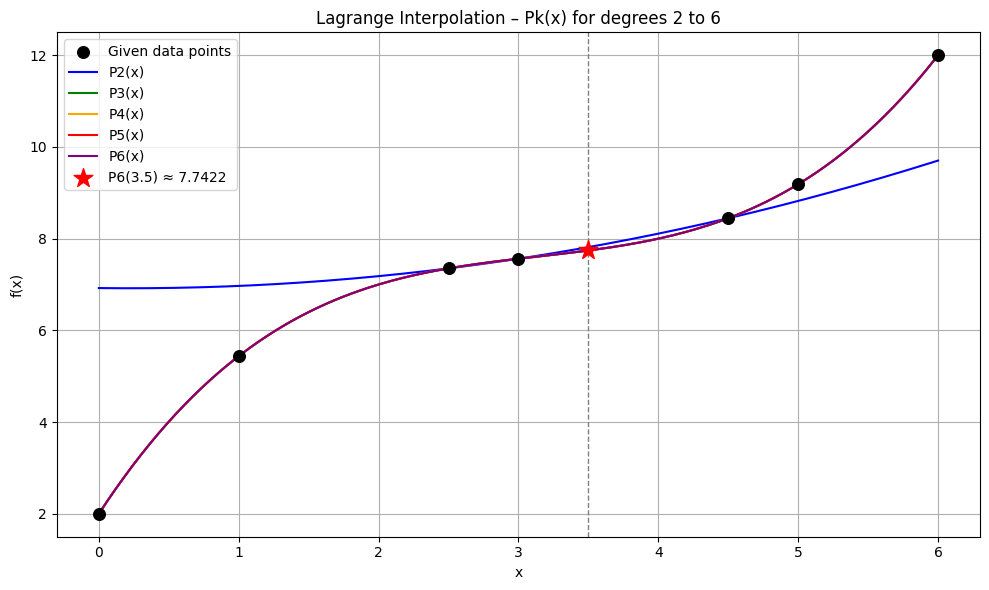


Plot saved as  Lagrange_plot.png


In [36]:
x_plot = np.linspace(0, 6, 300)   # 300 points from 0 to 6
 
plt.figure(figsize=(10, 6))
 
# plot the original data points
plt.scatter(x_data, y_data, color='black', zorder=5,
            label='Given data points', s=70)
 
# one curve for each degree
colors = ['blue', 'green', 'orange', 'red', 'purple']
for idx, (k, val, delta) in enumerate(results_table):
    num_nodes = k + 1
    x_nodes, y_nodes = get_closest_nodes(x_data, y_data, TARGET, num_nodes)
 
    # evaluate polynomial at every x_plot value
    y_plot = [lagrange_interpolate(x_nodes, y_nodes, xi) for xi in x_plot]
 
    plt.plot(x_plot, y_plot, color=colors[idx], label=f'P{k}(x)')
 
# mark the target point
best_val = results_table[-1][1]   # P6 value (highest degree)
plt.axvline(x=TARGET, color='gray', linestyle='--', linewidth=1)
plt.scatter([TARGET], [best_val], color='red', zorder=6,
            marker='*', s=200, label=f'P6({TARGET}) ≈ {best_val:.4f}')
 
plt.title("Lagrange Interpolation – Pk(x) for degrees 2 to 6")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Lagrange_plot.png", dpi=150)
plt.show()
print("\nPlot saved as  Lagrange_plot.png")
 

Convergence bar chart (|Δk| vs degree)

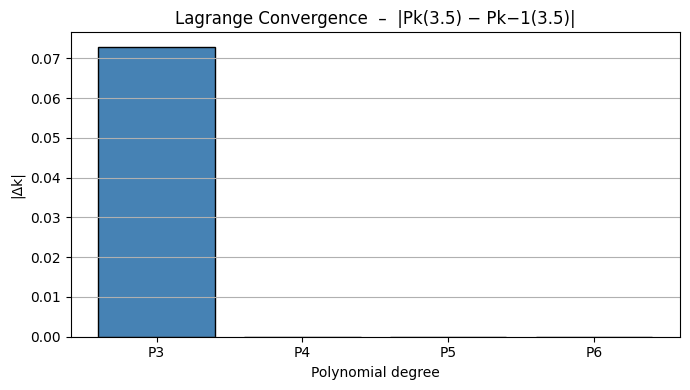

Convergence plot saved as  Lagrange_convergence.png


In [37]:
degrees = [row[0] for row in results_table[1:]]    # P3 onwards have a delta
deltas  = [float(row[2]) for row in results_table[1:]]
 
plt.figure(figsize=(7, 4))
plt.bar([f"P{k}" for k in degrees], deltas, color='steelblue', edgecolor='black')
plt.title("Lagrange Convergence  –  |Pk(3.5) − Pk−1(3.5)|")
plt.xlabel("Polynomial degree")
plt.ylabel("|Δk|")
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("Lagrange_convergence.png", dpi=150)
plt.show()
print("Convergence plot saved as  Lagrange_convergence.png")